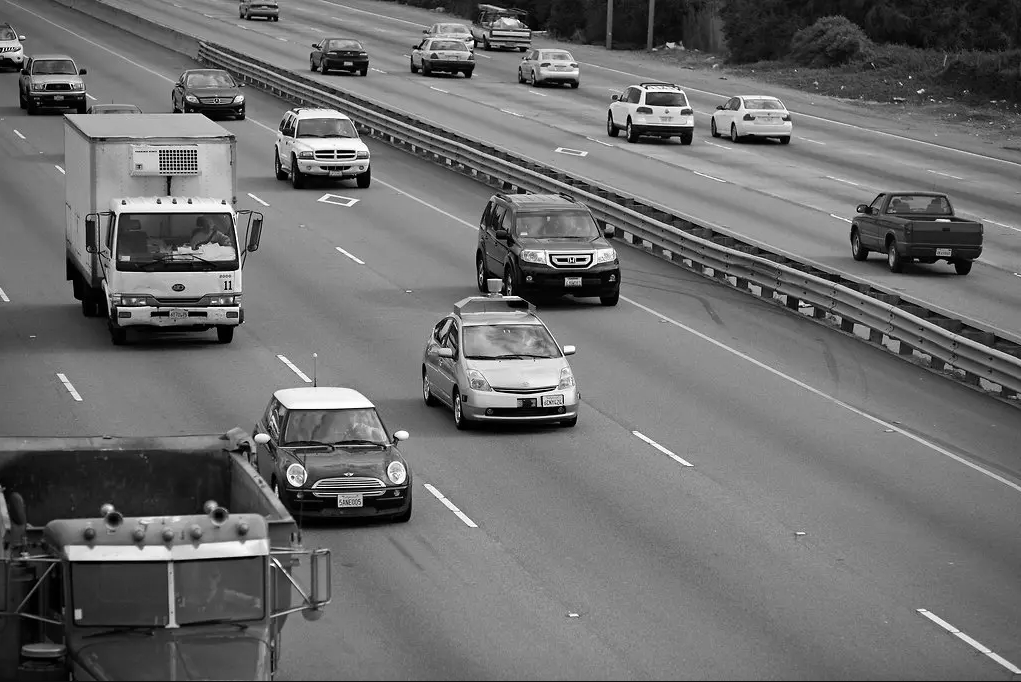

In [ ]:
import cv2

from google.colab.patches import cv2_imshow

img = cv2.imread('input.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

cv2_imshow(gray)



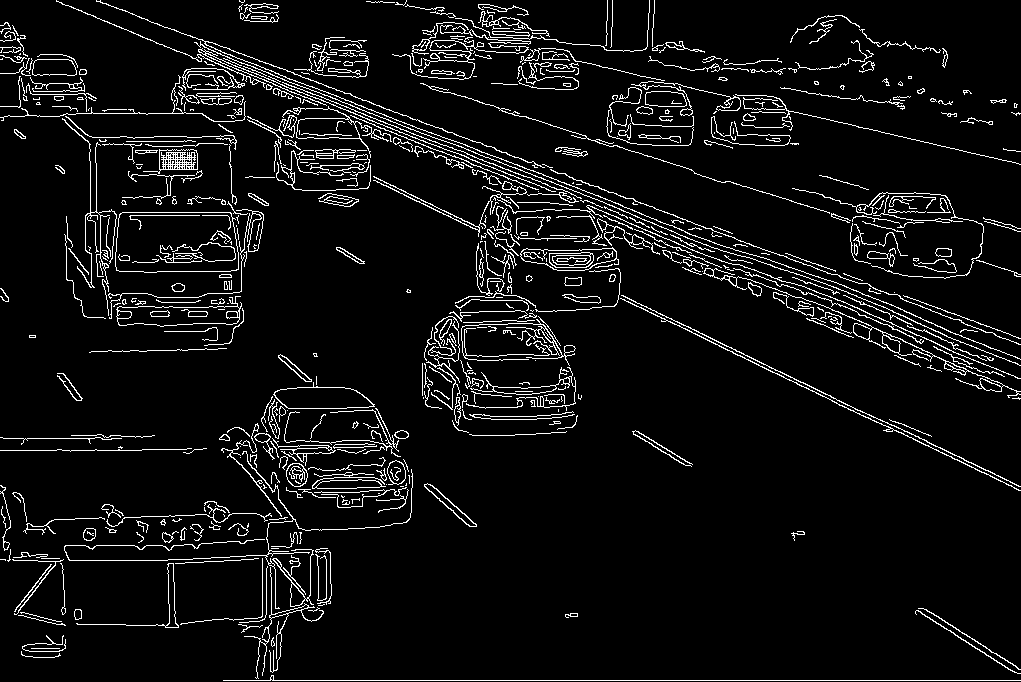

In [ ]:
import cv2

img = cv2.imread('input.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Reduce noise before edge detection
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Detect edges using lower and upper thresholds
edges = cv2.Canny(blurred, 50, 150)

cv2_imshow(edges)


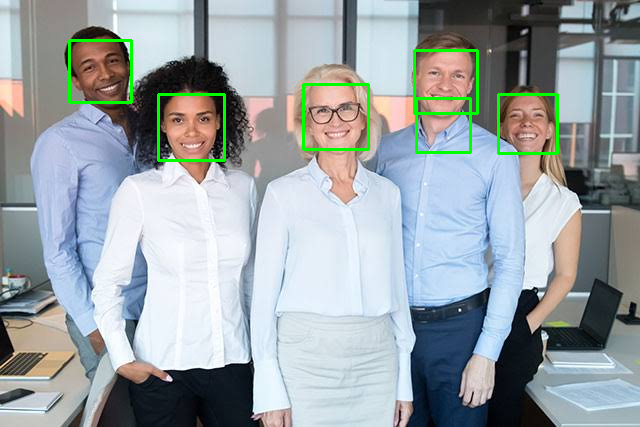

In [ ]:
import cv2

img = cv2.imread('people.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Load OpenCV's pretrained face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Detect faces: returns list of (x, y, w, h) boxes
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=3)

# Draw a rectangle around each detected face
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

cv2_imshow(img)


In [ ]:
import urllib.request
import os

prototxt_url = 'https://raw.githubusercontent.com/chuanqi305/MobileNet-SSD/master/deploy.prototxt'
caffemodel_url = 'https://raw.githubusercontent.com/chuanqi305/MobileNet-SSD/master/mobilenet_iter_73000.caffemodel'

print('Downloading deploy.prototxt...')
urllib.request.urlretrieve(prototxt_url, 'MobileNetSSD_deploy.prototxt')

print('Downloading mobilenet_iter_73000.caffemodel...')
urllib.request.urlretrieve(caffemodel_url, 'MobileNetSSD_deploy.caffemodel')

# Sanity check — the caffemodel should be ~23 MB, not a few KB
print(os.path.getsize('MobileNetSSD_deploy.prototxt'), 'bytes (prototxt)')
print(os.path.getsize('MobileNetSSD_deploy.caffemodel'), 'bytes (caffemodel, expect ~23,147,564)')

44667 bytes (prototxt)
23306119 bytes (caffemodel, expect ~23,147,564)


In [ ]:
net = cv2.dnn.readNetFromCaffe('MobileNetSSD_deploy.prototxt', 'MobileNetSSD_deploy.caffemodel')
print("Model loaded successfully:", net is not None)

Model loaded successfully: True


Detected 5 object(s) above confidence threshold


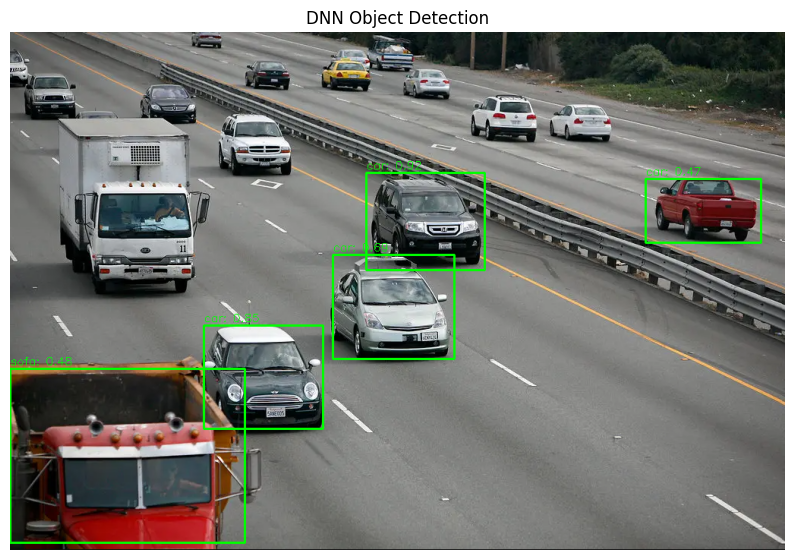

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# --- Sanity checks before loading anything ---
for f in ['MobileNetSSD_deploy.prototxt', 'MobileNetSSD_deploy.caffemodel', 'input.png']:
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing file: {f} (check it's in {os.getcwd()})")

# Load pretrained Caffe model
net = cv2.dnn.readNetFromCaffe('MobileNetSSD_deploy.prototxt',
                                'MobileNetSSD_deploy.caffemodel')

classes = ["background", "aeroplane", "bicycle", "bird", "boat", "bottle",
           "bus", "car", "cat", "chair", "cow", "diningtable", "dog",
           "horse", "motorbike", "person", "pottedplant", "sheep",
           "sofa", "train", "tvmonitor"]

img = cv2.imread('input.png')
if img is None:
    raise ValueError("street.jpg failed to load — check the path/filename")

h, w = img.shape[:2]

# Preprocess: resize + normalize into a "blob" the network expects
blob = cv2.dnn.blobFromImage(img, 0.007843, (300, 300), 127.5)
net.setInput(blob)
detections = net.forward()

detected_count = 0
for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]
    if confidence > 0.4:   # keep only confident detections
        idx = int(detections[0, 0, i, 1])
        box = detections[0, 0, i, 3:7] * [w, h, w, h]
        (x1, y1, x2, y2) = box.astype("int")
        label = f"{classes[idx]}: {confidence:.2f}"
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (0, 255, 0), 1)
        detected_count += 1

print(f"Detected {detected_count} object(s) above confidence threshold")

# Notebooks: cv2.imshow doesn't render inline — use matplotlib instead
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert for correct colors
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('DNN Object Detection')
plt.show()

In [ ]:
!pip install waymo-open-dataset-tf-2-12-0 --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 16.6 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from waymo_open_dataset.protos import scenario_pb2

PARQUET_FILE = "/content/training_camera_image_10017090168044687777_6380_000_6400_000.parquet"

df = pd.read_parquet(PARQUET_FILE)

print(df.columns.tolist())
print(df.shape)
print(df.head(2))



['key.segment_context_name', 'key.frame_timestamp_micros', 'key.camera_name', '[CameraImageComponent].image', '[CameraImageComponent].pose.transform', '[CameraImageComponent].velocity.linear_velocity.x', '[CameraImageComponent].velocity.linear_velocity.y', '[CameraImageComponent].velocity.linear_velocity.z', '[CameraImageComponent].velocity.angular_velocity.x', '[CameraImageComponent].velocity.angular_velocity.y', '[CameraImageComponent].velocity.angular_velocity.z', '[CameraImageComponent].pose_timestamp', '[CameraImageComponent].rolling_shutter_params.shutter', '[CameraImageComponent].rolling_shutter_params.camera_trigger_time', '[CameraImageComponent].rolling_shutter_params.camera_readout_done_time']
(990, 15)
                                                                  key.segment_context_name  \
index                                                                                        
10017090168044687777_6380_000_6400_000;15500834...  10017090168044687777_6380_000_6400_00

In [ ]:
OUT_DIR = "/content/waymo_frames/cam_front"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_parquet(PARQUET_FILE)
front_df = df[df["key.camera_name"] == 1].sort_values("key.frame_timestamp_micros")
for i, (_, row) in enumerate(front_df.iterrows()):
    img_bytes = row["[CameraImageComponent].image"]
    img_array = cv2.imdecode(np.frombuffer(img_bytes, dtype=np.uint8), cv2.IMREAD_COLOR)
    cv2.imwrite(os.path.join(OUT_DIR, f"frame_{i:04d}.jpg"), img_array)

print(f"Extracted {len(front_df)} frames to {OUT_DIR}")



Extracted 198 frames to /content/waymo_frames/cam_front


In [ ]:
import glob
frame_files = sorted(glob.glob(os.path.join(OUT_DIR, "*.jpg")))
first = cv2.imread(frame_files[0])
h, w = first.shape[:2]

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("/content/cam_front.mp4", fourcc, 10, (w, h))


for f in frame_files:
    out.write(cv2.imread(f))

out.release()
print("Saved /content/cam_front.mp4")


Saved /content/cam_front.mp4


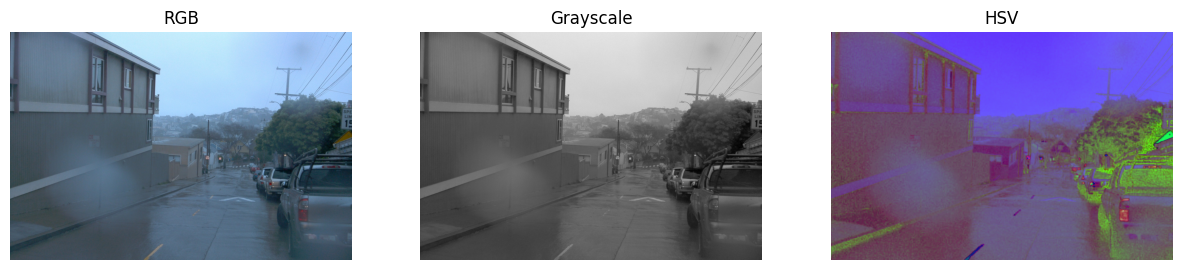

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/waymo_frames/cam_front/frame_0040.jpg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb); axes[0].set_title("RGB"); axes[0].axis("off")
axes[1].imshow(img_gray, cmap="gray"); axes[1].set_title("Grayscale"); axes[1].axis("off")
axes[2].imshow(img_hsv); axes[2].set_title("HSV"); axes[2].axis("off")
plt.show()


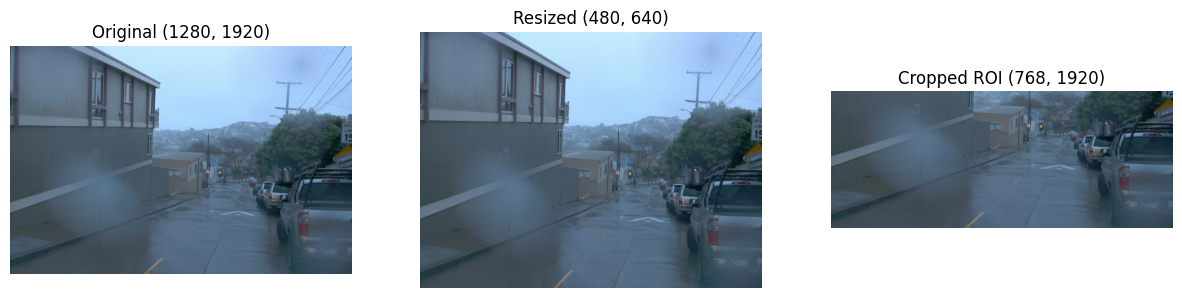

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/waymo_frames/cam_front/frame_0040.jpg")

# Resize for faster processing
resized = cv2.resize(img, (640, 480))

# Crop out the sky, keep the road-relevant bottom region
h, w = img.shape[:2]
road_roi = img[int(h * 0.4):h, :]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title(f"Original {img.shape[:2]}"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)); axes[1].set_title(f"Resized {resized.shape[:2]}"); axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(road_roi, cv2.COLOR_BGR2RGB)); axes[2].set_title(f"Cropped ROI {road_roi.shape[:2]}"); axes[2].axis("off")
plt.show()

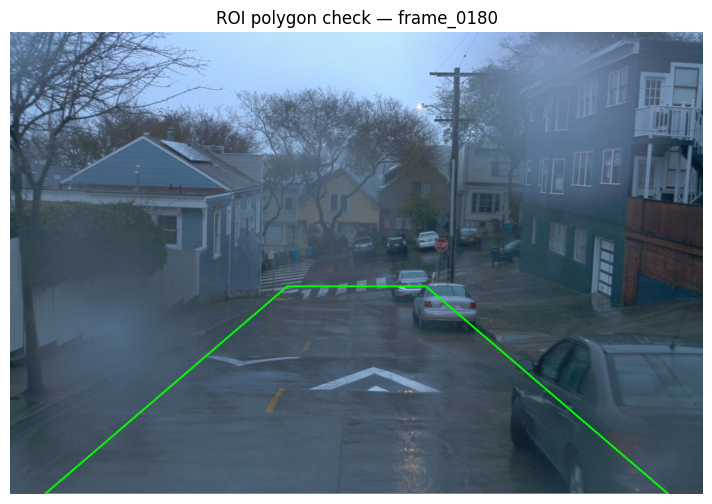

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/waymo_frames/cam_front/frame_0180.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

# Step 1: Check the ROI polygon against this frame
h, w = img.shape[:2]
polygon = np.array([[
    (int(w * 0.05), h),
    (int(w * 0.40), int(h * 0.55)),
    (int(w * 0.60), int(h * 0.55)),
    (int(w * 0.95), h),
]], dtype=np.int32)

mask_vis = img.copy()
cv2.polylines(mask_vis, polygon, isClosed=True, color=(0, 255, 0), thickness=3)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(mask_vis, cv2.COLOR_BGR2RGB))
plt.title("ROI polygon check — frame_0180")
plt.axis("off")
plt.show()